In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

warnings.filterwarnings('ignore')
%matplotlib inline

Dataset Shape: (2200, 8)

Missing Values:
 N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


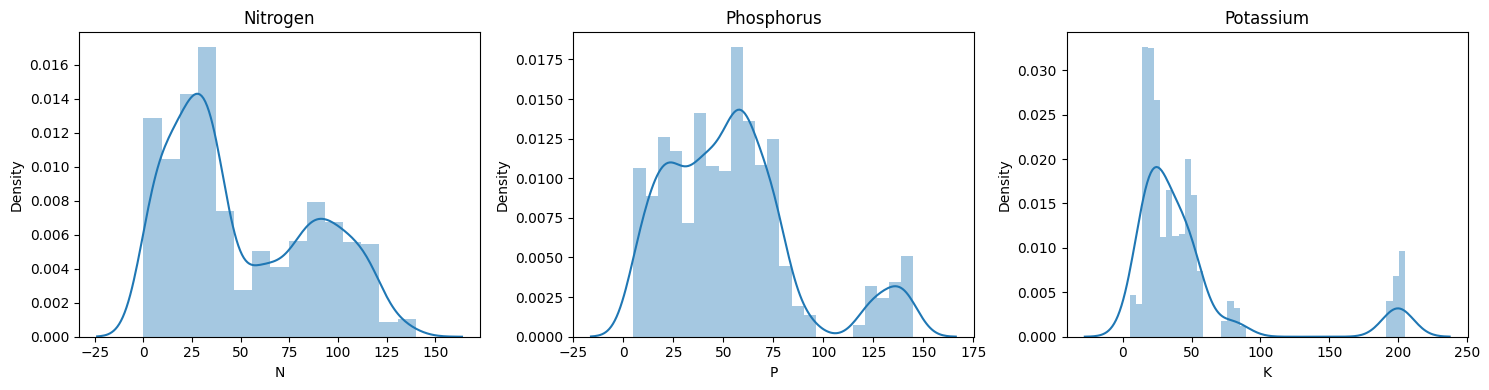

ValueError: could not convert string to float: 'rice'

<Figure size 800x600 with 0 Axes>

In [2]:
crop = pd.read_csv('Crop_recommendation.csv')

print("Dataset Shape:", crop.shape)
print("\nMissing Values:\n", crop.isnull().sum())

# Visualizing Distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.distplot(crop['N'], ax=axes[0], label='N').set_title('Nitrogen')
sns.distplot(crop['P'], ax=axes[1], label='P').set_title('Phosphorus')
sns.distplot(crop['K'], ax=axes[2], label='K').set_title('Potassium')
plt.tight_layout()
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(crop.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

In [3]:
crop_dict = {
    'rice': 1, 'maize': 2, 'jute': 3, 'cotton': 4, 'papaya': 5,
    'orange': 6, 'apple': 7, 'muskmelon': 8, 'watermelon': 9,
    'grapes': 10, 'mango': 11, 'banana': 12, 'pomegranate': 13,
    'lentil': 14, 'blackgram': 15, 'mungbean': 16, 'mothbeans': 17,
    'pigeonpeas': 18, 'kidneybeans': 19, 'chickpea': 20, 'coffee': 21,
    'coconut': 22
}

crop['label'] = crop['label'].map(crop_dict)
X = crop.drop('label', axis=1)
y = crop['label']

# Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data split and scaled successfully.")

Data split and scaled successfully.


In [4]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Gaussian NB": GaussianNB(),
    "SVC": SVC(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier()
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    print(f"{name} Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# Select Random Forest as the 'best_model' for the next steps
best_model = models["Random Forest"]

Logistic Regression Accuracy: 0.9705
Gaussian NB Accuracy: 0.9955
SVC Accuracy: 0.9795
Random Forest Accuracy: 1.0000
Gradient Boosting Accuracy: 0.9955



Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       1.00      1.00      1.00        20
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        20
          11       1.00      1.00      1.00        20
          12       1.00      1.00      1.00        20
          13       1.00      1.00      1.00        20
          14       1.00      1.00      1.00        20
          15       1.00      1.00      1.00        20
          16       1.00      1.00      1.00        20
          17       1.00      1.00      1.00        20
  

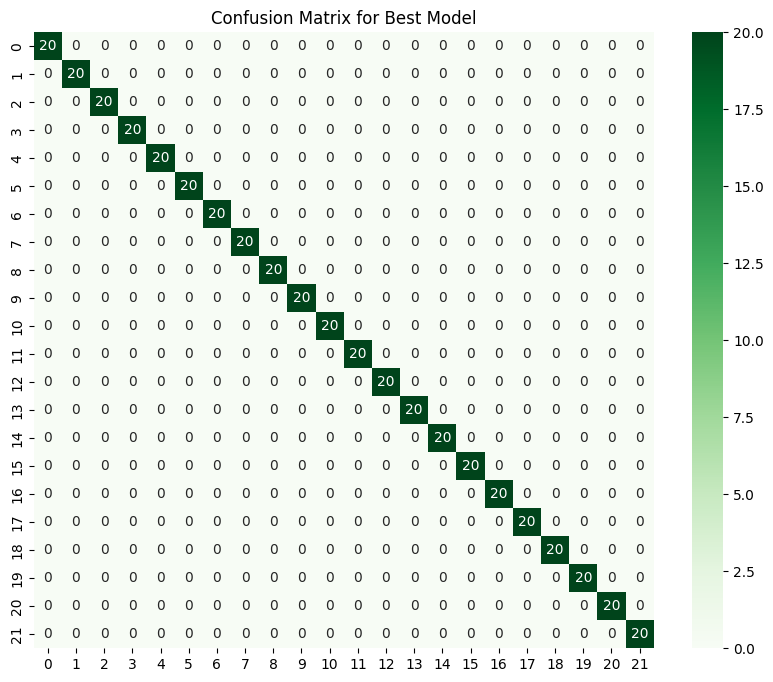

In [5]:
y_pred = best_model.predict(X_test_scaled)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix for Best Model")
plt.show()

In [6]:
pickle.dump(best_model, open('crop_recommendation_model.pkl', 'wb'))
pickle.dump(scaler, open('feature_scaler.pkl', 'wb'))
pickle.dump(crop_dict, open('crop_encoding.pkl', 'wb'))

print("Files saved: 'crop_recommendation_model.pkl', 'feature_scaler.pkl', 'crop_encoding.pkl'")

Files saved: 'crop_recommendation_model.pkl', 'feature_scaler.pkl', 'crop_encoding.pkl'


In [10]:
inverse_crop_dict = {v: k for k, v in crop_dict.items()}

def recommend_crop(N, P, K, temp, hum, ph, rain):
    features = np.array([[N, P, K, temp, hum, ph, rain]])
    scaled_features = scaler.transform(features)
    prediction = best_model.predict(scaled_features)[0]
    return inverse_crop_dict[prediction]

# Example Test
result = recommend_crop(100, 42, 48, 20.8, 8.0, 6.5, 202.9)
print(f"Recommended Crop: {result}")

Recommended Crop: kidneybeans
